# Weather-Caused Flight Delay Classification

This notebook targets **weather-caused delay only**.

Target definition:

`WeatherDelayed = 1 if WeatherDelay > 30 else 0`

The model predicts whether the **official delay cause** was weather. Flight data is used to create the label and match scheduled origin/destination weather, but delay-causing columns are not used as model predictors.

In [26]:
# Section 1 — Settings and imports

import gc
import joblib
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay,
)

warnings.filterwarnings("ignore")
pd.options.display.max_rows = 20
pd.options.display.max_columns = 60

# Default: 2022+ to reduce Kaggle memory.
# Add 2019, 2020, 2021 if your RAM can handle it.
FLIGHT_FILES = [
    "/kaggle/input/datasets/kamalalqedra/bts-ontime-performance-2019-present-csv/bts_ontime_2019.csv",
    "/kaggle/input/datasets/kamalalqedra/bts-ontime-performance-2019-present-csv/bts_ontime_2021.csv",
    "/kaggle/input/datasets/kamalalqedra/bts-ontime-performance-2019-present-csv/bts_ontime_2020.csv",
    "/kaggle/input/datasets/kamalalqedra/bts-ontime-performance-2019-present-csv/bts_ontime_2022.csv",
    "/kaggle/input/datasets/kamalalqedra/bts-ontime-performance-2019-present-csv/bts_ontime_2023.csv",
    "/kaggle/input/datasets/kamalalqedra/bts-ontime-performance-2019-present-csv/bts_ontime_2024.csv",
    "/kaggle/input/datasets/kamalalqedra/bts-ontime-performance-2019-present-csv/bts_ontime_2025.csv",
    "/kaggle/input/datasets/kamalalqedra/bts-ontime-performance-2019-present-csv/bts_ontime_2026.csv",
]

WEATHER_PATH = "/kaggle/input/datasets/sehamhakimothman/asos-weather-data-2019-2026/historical_weather_data_2019_2026.csv"

WEATHER_DELAY_TARGET_THRESHOLD_MINUTES = 0
WEATHER_TOLERANCE = "3h"
PREDICTION_THRESHOLD = 0.50
TEST_SPLIT_DATE = "2025-01-01"
RANDOM_STATE = 42
MLP_MAX_ITER = 80

FINAL_MODEL_FILE = "final_weather_cause_delay_model.joblib"
FINAL_THRESHOLD_FILE = "final_weather_cause_prediction_threshold.joblib"
FINAL_DATASET_FILE = "final_weather_cause_modeling_dataset.parquet"

## Section 2 — Check input files

In [27]:
file_check = []
for file_path in FLIGHT_FILES:
    file_check.append({"file": Path(file_path).name, "exists": Path(file_path).exists(), "path": file_path})
file_check.append({"file": Path(WEATHER_PATH).name, "exists": Path(WEATHER_PATH).exists(), "path": WEATHER_PATH})
file_check_df = pd.DataFrame(file_check)
display(file_check_df)
if not file_check_df["exists"].all():
    raise FileNotFoundError("Some input files are missing. Check the paths above.")

,file,exists,path
0,bts_ontime_2019.csv,True,/kaggle/input/datasets/kamalalqedra/bts-ontime...
1,bts_ontime_2021.csv,True,/kaggle/input/datasets/kamalalqedra/bts-ontime...
2,bts_ontime_2020.csv,True,/kaggle/input/datasets/kamalalqedra/bts-ontime...
3,bts_ontime_2022.csv,True,/kaggle/input/datasets/kamalalqedra/bts-ontime...
4,bts_ontime_2023.csv,True,/kaggle/input/datasets/kamalalqedra/bts-ontime...
5,bts_ontime_2024.csv,True,/kaggle/input/datasets/kamalalqedra/bts-ontime...
6,bts_ontime_2025.csv,True,/kaggle/input/datasets/kamalalqedra/bts-ontime...
7,bts_ontime_2026.csv,True,/kaggle/input/datasets/kamalalqedra/bts-ontime...
8,historical_weather_data_2019_2026.csv,True,/kaggle/input/datasets/sehamhakimothman/asos-w...


## Section 3 — Load flight data and detect WeatherDelay column

In [28]:
base_flight_cols = ["FlightDate", "Origin", "OriginState", "Dest", "DestState", "CRSDepTime", "CRSArrTime"]
candidate_weather_delay_cols = ["WeatherDelay", "WEATHER_DELAY", "Weather_Delay", "weather_delay"]

flight_parts = []
detected_weather_delay_cols = []

for file_path in FLIGHT_FILES:
    file_path = Path(file_path)
    header = pd.read_csv(file_path, nrows=0).columns.str.strip().tolist()

    weather_delay_col = None
    for candidate in candidate_weather_delay_cols:
        if candidate in header:
            weather_delay_col = candidate
            break
    if weather_delay_col is None:
        lower_map = {c.lower(): c for c in header}
        for candidate in candidate_weather_delay_cols:
            if candidate.lower() in lower_map:
                weather_delay_col = lower_map[candidate.lower()]
                break
    if weather_delay_col is None:
        raise ValueError(f"No WeatherDelay/WEATHER_DELAY column found in {file_path.name}. Check the dataset columns.")

    detected_weather_delay_cols.append(weather_delay_col)
    usecols = [col for col in base_flight_cols if col in header] + [weather_delay_col]
    part = pd.read_csv(file_path, usecols=usecols, low_memory=False)
    part.columns = part.columns.str.strip()
    part = part.rename(columns={weather_delay_col: "WeatherDelay"})
    part["source_file"] = file_path.name
    flight_parts.append(part)

flights = pd.concat(flight_parts, ignore_index=True)
del flight_parts
gc.collect()

flights["FlightDate"] = pd.to_datetime(flights["FlightDate"], errors="coerce")
for col in ["Origin", "OriginState", "Dest", "DestState", "source_file"]:
    if col in flights.columns:
        flights[col] = flights[col].astype("string").str.strip().str.upper().astype("category")
for col in ["CRSDepTime", "CRSArrTime", "WeatherDelay"]:
    if col in flights.columns:
        flights[col] = pd.to_numeric(flights[col], errors="coerce").astype("float32")

summary = pd.DataFrame({
    "item": ["Flight files loaded", "Flight rows", "Detected weather delay columns", "First flight date", "Last flight date", "Memory usage MB"],
    "value": [len(FLIGHT_FILES), len(flights), sorted(set(detected_weather_delay_cols)), flights["FlightDate"].min(), flights["FlightDate"].max(), round(flights.memory_usage(deep=True).sum()/1024**2, 2)]
})
display(summary)

,item,value
0,Flight files loaded,8
1,Flight rows,46307495
2,Detected weather delay columns,[WeatherDelay]
3,First flight date,2019-01-01 00:00:00
4,Last flight date,2026-01-31 00:00:00
5,Memory usage MB,1192.45


## Section 4 — Create target and scheduled local datetimes

,class,count,percentage
0,No official weather delay,8166011,0.940018
1,Weather delay,521066,0.059982


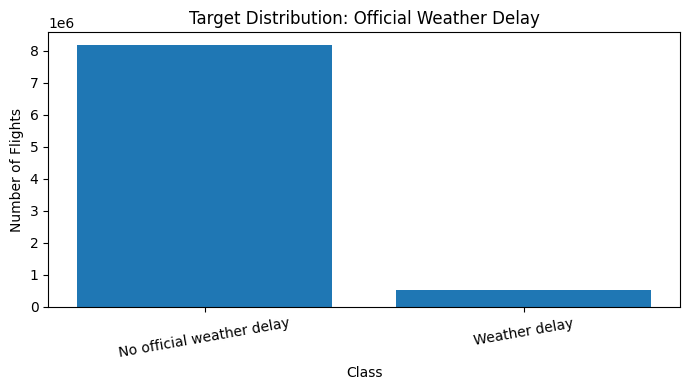

In [29]:
flights = flights.dropna(subset=["FlightDate", "Origin", "Dest", "CRSDepTime", "CRSArrTime", "WeatherDelay"]).copy()
flights["WeatherDelayed"] = (flights["WeatherDelay"] > WEATHER_DELAY_TARGET_THRESHOLD_MINUTES).astype("int8")

def make_local_datetime(date_series, time_series):
    time_num = pd.to_numeric(time_series, errors="coerce")
    hours = (time_num // 100).astype("float")
    minutes = (time_num % 100).astype("float")
    hours = hours.where(hours < 24, 0)
    return pd.to_datetime(date_series, errors="coerce") + pd.to_timedelta(hours, unit="h") + pd.to_timedelta(minutes, unit="m")

flights["sched_dep_local"] = make_local_datetime(flights["FlightDate"], flights["CRSDepTime"])
flights["sched_arr_local"] = make_local_datetime(flights["FlightDate"], flights["CRSArrTime"])
overnight = flights["sched_arr_local"] < flights["sched_dep_local"]
flights.loc[overnight, "sched_arr_local"] = flights.loc[overnight, "sched_arr_local"] + pd.Timedelta(days=1)

target_summary = flights["WeatherDelayed"].value_counts().rename(index={0:"No official weather delay", 1:"Weather delay"}).reset_index()
target_summary.columns = ["class", "count"]
target_summary["percentage"] = target_summary["count"] / target_summary["count"].sum()
display(target_summary)

plt.figure(figsize=(7, 4))
plt.bar(target_summary["class"], target_summary["count"])
plt.title("Target Distribution: Official Weather Delay")
plt.xlabel("Class")
plt.ylabel("Number of Flights")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

## Section 5 — Convert scheduled departure and arrival to UTC

In [30]:
state_to_tz = {
    "AL":"America/Chicago", "AK":"America/Anchorage", "AZ":"America/Phoenix", "AR":"America/Chicago",
    "CA":"America/Los_Angeles", "CO":"America/Denver", "CT":"America/New_York", "DE":"America/New_York",
    "FL":"America/New_York", "GA":"America/New_York", "HI":"Pacific/Honolulu", "IA":"America/Chicago",
    "ID":"America/Denver", "IL":"America/Chicago", "IN":"America/Indiana/Indianapolis", "KS":"America/Chicago",
    "KY":"America/New_York", "LA":"America/Chicago", "MA":"America/New_York", "MD":"America/New_York",
    "ME":"America/New_York", "MI":"America/New_York", "MN":"America/Chicago", "MO":"America/Chicago",
    "MS":"America/Chicago", "MT":"America/Denver", "NC":"America/New_York", "ND":"America/Chicago",
    "NE":"America/Chicago", "NH":"America/New_York", "NJ":"America/New_York", "NM":"America/Denver",
    "NV":"America/Los_Angeles", "NY":"America/New_York", "OH":"America/New_York", "OK":"America/Chicago",
    "OR":"America/Los_Angeles", "PA":"America/New_York", "RI":"America/New_York", "SC":"America/New_York",
    "SD":"America/Chicago", "TN":"America/Chicago", "TX":"America/Chicago", "UT":"America/Denver",
    "VA":"America/New_York", "VT":"America/New_York", "WA":"America/Los_Angeles", "WI":"America/Chicago",
    "WV":"America/New_York", "WY":"America/Denver", "PR":"America/Puerto_Rico", "VI":"America/Puerto_Rico",
    "GU":"Pacific/Guam", "TT":"America/Puerto_Rico",
}

airport_tz_overrides = {
    "EVV":"America/Chicago", "SBN":"America/Indiana/Indianapolis", "CVG":"America/New_York",
    "OWB":"America/Chicago", "PAH":"America/Chicago", "BNA":"America/Chicago", "MEM":"America/Chicago",
    "TYS":"America/New_York", "TRI":"America/New_York", "CHA":"America/New_York",
    "ECP":"America/Chicago", "PNS":"America/Chicago", "VPS":"America/Chicago", "ELP":"America/Denver",
    "BOI":"America/Denver", "PIH":"America/Denver", "TWF":"America/Denver", "PHX":"America/Phoenix",
    "TUS":"America/Phoenix", "FLG":"America/Phoenix", "ANC":"America/Anchorage", "FAI":"America/Anchorage",
    "JNU":"America/Juneau", "KTN":"America/Sitka", "SIT":"America/Sitka", "OME":"America/Nome",
    "HNL":"Pacific/Honolulu", "OGG":"Pacific/Honolulu", "KOA":"Pacific/Honolulu", "LIH":"Pacific/Honolulu",
    "SJU":"America/Puerto_Rico", "STT":"America/Puerto_Rico", "STX":"America/Puerto_Rico",
    "GUM":"Pacific/Guam", "SPN":"Pacific/Saipan", "PPG":"Pacific/Pago_Pago",
}

flights["OriginTimezone"] = flights["OriginState"].astype("string").map(state_to_tz)
flights["OriginTimezone"] = flights["Origin"].astype("string").map(airport_tz_overrides).fillna(flights["OriginTimezone"])
flights["DestTimezone"] = flights["DestState"].astype("string").map(state_to_tz)
flights["DestTimezone"] = flights["Dest"].astype("string").map(airport_tz_overrides).fillna(flights["DestTimezone"])

def add_utc_time_by_timezone(df, local_col, tz_col, out_col):
    df[out_col] = pd.NaT
    for tz, idx in df.groupby(tz_col, dropna=True).groups.items():
        local_times = pd.to_datetime(df.loc[idx, local_col], errors="coerce")
        utc_times = local_times.dt.tz_localize(tz, ambiguous="NaT", nonexistent="shift_forward").dt.tz_convert("UTC").dt.tz_localize(None)
        df.loc[idx, out_col] = utc_times
    return df

flights = add_utc_time_by_timezone(flights, "sched_dep_local", "OriginTimezone", "sched_dep_utc")
flights = add_utc_time_by_timezone(flights, "sched_arr_local", "DestTimezone", "sched_arr_utc")

display(pd.DataFrame({
    "item": ["Flights before UTC filtering", "Flights with scheduled departure UTC", "Flights with scheduled arrival UTC"],
    "value": [len(flights), flights["sched_dep_utc"].notna().sum(), flights["sched_arr_utc"].notna().sum()]
}))
flights = flights[flights["sched_dep_utc"].notna() & flights["sched_arr_utc"].notna()].copy()
gc.collect()

,item,value
0,Flights before UTC filtering,8687077
1,Flights with scheduled departure UTC,8687070
2,Flights with scheduled arrival UTC,8687066


422

## Section 6 — Load ASOS weather data in chunks

In [31]:
station_special_map = {
    "PANC":"ANC", "PAFA":"FAI", "PAJN":"JNU", "PAKT":"KTN", "PASI":"SIT", "PAOM":"OME",
    "PABR":"BRW", "PABE":"BET", "PADQ":"ADQ", "PAHO":"HOM", "PAEN":"ENA", "PAVD":"VDZ",
    "PHNL":"HNL", "PHOG":"OGG", "PHKO":"KOA", "PHLI":"LIH", "PHTO":"ITO",
    "TJSJ":"SJU", "TJBQ":"BQN", "TJPS":"PSE", "TIST":"STT", "TISX":"STX",
    "PGUM":"GUM", "PGSN":"SPN", "NSTU":"PPG",
}

def station_to_iata(station_series):
    s = station_series.astype("string").str.strip().str.upper()
    mapped = s.map(station_special_map)
    k_rule = s.str.replace(r"^K(?=[A-Z]{3}$)", "", regex=True)
    return mapped.fillna(k_rule)

weather_cols = ["station", "valid", "tmpf", "dwpf", "relh", "drct", "sknt", "p01i", "alti", "mslp", "vsby", "gust", "skyc1", "skyc2", "wxcodes", "feel"]
weather_header = pd.read_csv(WEATHER_PATH, nrows=0).columns.str.strip().tolist()
weather_usecols = [col for col in weather_cols if col in weather_header]
needed_airports = set(pd.concat([flights["Origin"].astype("string"), flights["Dest"].astype("string")]).dropna().unique())
min_weather_time = min(flights["sched_dep_utc"].min(), flights["sched_arr_utc"].min()) - pd.Timedelta(WEATHER_TOLERANCE)
max_weather_time = max(flights["sched_dep_utc"].max(), flights["sched_arr_utc"].max()) + pd.Timedelta("1d")

weather_parts = []
for chunk in pd.read_csv(WEATHER_PATH, usecols=weather_usecols, chunksize=1_000_000, low_memory=False, na_values=["M", ""]):
    chunk.columns = chunk.columns.str.strip()
    chunk["weather_iata"] = station_to_iata(chunk["station"])
    chunk = chunk[chunk["weather_iata"].isin(needed_airports)]
    if len(chunk) == 0:
        continue
    chunk["valid_utc"] = pd.to_datetime(chunk["valid"], errors="coerce", utc=True).dt.tz_localize(None)
    chunk = chunk[(chunk["valid_utc"] >= min_weather_time) & (chunk["valid_utc"] <= max_weather_time)]
    if len(chunk) == 0:
        continue
    for col in ["tmpf", "dwpf", "relh", "drct", "sknt", "p01i", "alti", "mslp", "vsby", "gust", "feel"]:
        if col in chunk.columns:
            chunk[col] = pd.to_numeric(chunk[col], errors="coerce").astype("float32")
    if "wxcodes" in chunk.columns:
        chunk["wxcodes"] = chunk["wxcodes"].fillna("NONE").astype("string")
    for col in ["skyc1", "skyc2"]:
        if col in chunk.columns:
            chunk[col] = chunk[col].fillna("NONE").astype("string")
    weather_parts.append(chunk)

if len(weather_parts) == 0:
    raise ValueError("No weather rows matched the needed airports and time range.")
weather = pd.concat(weather_parts, ignore_index=True)
del weather_parts
gc.collect()

display(pd.DataFrame({
    "item": ["Weather rows after filtering", "Weather columns", "Matched weather airports", "First weather time", "Last weather time", "Memory usage MB"],
    "value": [len(weather), weather.shape[1], weather["weather_iata"].nunique(), weather["valid_utc"].min(), weather["valid_utc"].max(), round(weather.memory_usage(deep=True).sum()/1024**2, 2)]
}))

,item,value
0,Weather rows after filtering,849974
1,Weather columns,18
2,Matched weather airports,11
3,First weather time,2019-01-01 03:32:00
4,Last weather time,2026-02-02 23:42:00
5,Memory usage MB,306.97


## Section 7 — Match flights with origin and destination weather

In [32]:
weather = weather.sort_values(["weather_iata", "valid_utc"]).reset_index(drop=True)

def merge_scheduled_weather(flights_df, weather_df, airport_col, time_col, prefix, tolerance=WEATHER_TOLERANCE):
    parts = []
    tolerance = pd.Timedelta(tolerance)
    weather_cols_to_prefix = [col for col in weather_df.columns if col not in ["station", "weather_iata", "valid", "valid_utc"]]
    flight_airports = set(flights_df[airport_col].astype("string").dropna().unique())
    weather_df = weather_df[weather_df["weather_iata"].isin(flight_airports)].copy()
    for airport, f_part in flights_df.groupby(airport_col, sort=False):
        w_part = weather_df[weather_df["weather_iata"] == str(airport)].copy()
        if len(w_part) == 0:
            continue
        merged = pd.merge_asof(
            f_part.sort_values(time_col),
            w_part.sort_values("valid_utc"),
            left_on=time_col,
            right_on="valid_utc",
            direction="backward",
            tolerance=tolerance,
        )
        parts.append(merged)
    if len(parts) == 0:
        raise ValueError(f"No weather matches found for {prefix}.")
    out = pd.concat(parts, ignore_index=True)
    rename_map = {col: f"{prefix}_{col}" for col in weather_cols_to_prefix}
    rename_map.update({"valid_utc": f"{prefix}_valid_utc", "valid": f"{prefix}_valid", "station": f"{prefix}_station", "weather_iata": f"{prefix}_iata"})
    return out.rename(columns=rename_map)

model_data = merge_scheduled_weather(flights, weather, "Origin", "sched_dep_utc", "origin_wx")
model_data = model_data[model_data["origin_wx_valid_utc"].notna()].copy()
model_data = merge_scheduled_weather(model_data, weather, "Dest", "sched_arr_utc", "dest_wx")
model_data = model_data[model_data["dest_wx_valid_utc"].notna()].copy()

del weather, flights
gc.collect()

display(pd.DataFrame({
    "item": ["Rows after origin + destination weather match", "Origin airports matched", "Destination airports matched", "Weather-delay rate", "Memory usage MB"],
    "value": [len(model_data), model_data["Origin"].nunique(), model_data["Dest"].nunique(), round(model_data["WeatherDelayed"].mean(), 4), round(model_data.memory_usage(deep=True).sum()/1024**2, 2)]
}))

,item,value
0,Rows after origin + destination weather match,12338.0000
1,Origin airports matched,8.0000
2,Destination airports matched,8.0000
3,Weather-delay rate,0.1261
4,Memory usage MB,11.2800


## Section 8 — Create weather predictors

In [33]:
origin_codes = model_data["origin_wx_wxcodes"].fillna("NONE").astype("string")
dest_codes = model_data["dest_wx_wxcodes"].fillna("NONE").astype("string")
for prefix, codes in [("origin_wx", origin_codes), ("dest_wx", dest_codes)]:
    model_data[f"{prefix}_rain"] = codes.str.contains("RA", regex=False).astype("int8")
    model_data[f"{prefix}_snow"] = codes.str.contains("SN", regex=False).astype("int8")
    model_data[f"{prefix}_fog"] = codes.str.contains("FG|BR", regex=True).astype("int8")
    model_data[f"{prefix}_thunder"] = codes.str.contains("TS", regex=False).astype("int8")

numeric_weather_features = [
    "origin_wx_tmpf", "origin_wx_dwpf", "origin_wx_relh", "origin_wx_drct", "origin_wx_sknt", "origin_wx_p01i", "origin_wx_alti", "origin_wx_mslp", "origin_wx_vsby", "origin_wx_gust", "origin_wx_feel", "origin_wx_rain", "origin_wx_snow", "origin_wx_fog", "origin_wx_thunder",
    "dest_wx_tmpf", "dest_wx_dwpf", "dest_wx_relh", "dest_wx_drct", "dest_wx_sknt", "dest_wx_p01i", "dest_wx_alti", "dest_wx_mslp", "dest_wx_vsby", "dest_wx_gust", "dest_wx_feel", "dest_wx_rain", "dest_wx_snow", "dest_wx_fog", "dest_wx_thunder",
]
numeric_weather_features = [col for col in numeric_weather_features if col in model_data.columns]
categorical_weather_features = ["origin_wx_skyc1", "origin_wx_skyc2", "dest_wx_skyc1", "dest_wx_skyc2"]
categorical_weather_features = [col for col in categorical_weather_features if col in model_data.columns]
all_features = numeric_weather_features + categorical_weather_features

display(pd.DataFrame({"feature_type": ["numeric weather", "categorical weather", "total"], "count": [len(numeric_weather_features), len(categorical_weather_features), len(all_features)]}))
display(pd.DataFrame({"features_used": all_features}))

,feature_type,count
0,numeric weather,30
1,categorical weather,4
2,total,34


,features_used
0,origin_wx_tmpf
1,origin_wx_dwpf
2,origin_wx_relh
3,origin_wx_drct
4,origin_wx_sknt
...,...
29,dest_wx_thunder
30,origin_wx_skyc1
31,origin_wx_skyc2
32,dest_wx_skyc1


## Section 9 — Train/test split

In [34]:
split_date = pd.Timestamp(TEST_SPLIT_DATE)
train_df = model_data[model_data["FlightDate"] < split_date].copy()
test_df = model_data[model_data["FlightDate"] >= split_date].copy()
if len(train_df) == 0 or len(test_df) == 0:
    train_df, test_df = train_test_split(model_data, test_size=0.2, random_state=RANDOM_STATE, stratify=model_data["WeatherDelayed"])
X_train = train_df[all_features]
y_train = train_df["WeatherDelayed"].astype("int8")
X_test = test_df[all_features]
y_test = test_df["WeatherDelayed"].astype("int8")
display(pd.DataFrame({"dataset": ["train", "test"], "rows": [len(train_df), len(test_df)], "weather_delay_rate": [y_train.mean(), y_test.mean()]}))

,dataset,rows,weather_delay_rate
0,train,8567,0.128867
1,test,3771,0.119862


## Section 10 — Train Random Forest

In [35]:
rf_preprocess = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), numeric_weather_features),
        ("cat", Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore", dtype=np.float32))]), categorical_weather_features),
    ],
    sparse_threshold=1.0,
)
random_forest_model = Pipeline(steps=[
    ("preprocess", rf_preprocess),
    ("model", RandomForestClassifier(n_estimators=200, max_depth=20, min_samples_leaf=10, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1)),
])
random_forest_model.fit(X_train, y_train)
rf_proba = random_forest_model.predict_proba(X_test)[:, 1]
rf_pred = (rf_proba >= PREDICTION_THRESHOLD).astype(int)
rf_metrics = pd.DataFrame([{
    "model": "Random Forest", "target": "WeatherDelay > 0", "prediction_threshold": PREDICTION_THRESHOLD,
    "accuracy": accuracy_score(y_test, rf_pred), "precision_weather_delay": precision_score(y_test, rf_pred, zero_division=0),
    "recall_weather_delay": recall_score(y_test, rf_pred, zero_division=0), "f1_weather_delay": f1_score(y_test, rf_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, rf_proba), "average_precision": average_precision_score(y_test, rf_proba),
}])
display(rf_metrics)

,model,target,prediction_threshold,accuracy,precision_weather_delay,recall_weather_delay,f1_weather_delay,roc_auc,average_precision
0,Random Forest,WeatherDelay > 0,0.5,0.830549,0.301486,0.314159,0.307692,0.738698,0.259379


## Section 11 — Train Neural Network

In [36]:
nn_preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler(with_mean=False))]), numeric_weather_features),
        ("cat", Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore", dtype=np.float32))]), categorical_weather_features),
    ],
    sparse_threshold=1.0,
)
neural_network_model = Pipeline(steps=[
    ("preprocess", nn_preprocess),
    ("model", MLPClassifier(hidden_layer_sizes=(64, 32), activation="relu", solver="adam", alpha=0.0005, batch_size=512, learning_rate_init=0.001, max_iter=MLP_MAX_ITER, early_stopping=True, validation_fraction=0.1, n_iter_no_change=8, random_state=RANDOM_STATE, verbose=False)),
])
neural_network_model.fit(X_train, y_train)
nn_proba = neural_network_model.predict_proba(X_test)[:, 1]
nn_pred = (nn_proba >= PREDICTION_THRESHOLD).astype(int)
nn_metrics = pd.DataFrame([{
    "model": "Neural Network", "target": "WeatherDelay > 0", "prediction_threshold": PREDICTION_THRESHOLD,
    "accuracy": accuracy_score(y_test, nn_pred), "precision_weather_delay": precision_score(y_test, nn_pred, zero_division=0),
    "recall_weather_delay": recall_score(y_test, nn_pred, zero_division=0), "f1_weather_delay": f1_score(y_test, nn_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, nn_proba), "average_precision": average_precision_score(y_test, nn_proba),
}])
display(nn_metrics)

,model,target,prediction_threshold,accuracy,precision_weather_delay,recall_weather_delay,f1_weather_delay,roc_auc,average_precision
0,Neural Network,WeatherDelay > 0,0.5,0.879608,0.416667,0.011062,0.021552,0.662943,0.208363


## Section 12 — Compare models

,model,target,prediction_threshold,accuracy,precision_weather_delay,recall_weather_delay,f1_weather_delay,roc_auc,average_precision
0,Random Forest,WeatherDelay > 0,0.5,0.830549,0.301486,0.314159,0.307692,0.738698,0.259379
1,Neural Network,WeatherDelay > 0,0.5,0.879608,0.416667,0.011062,0.021552,0.662943,0.208363


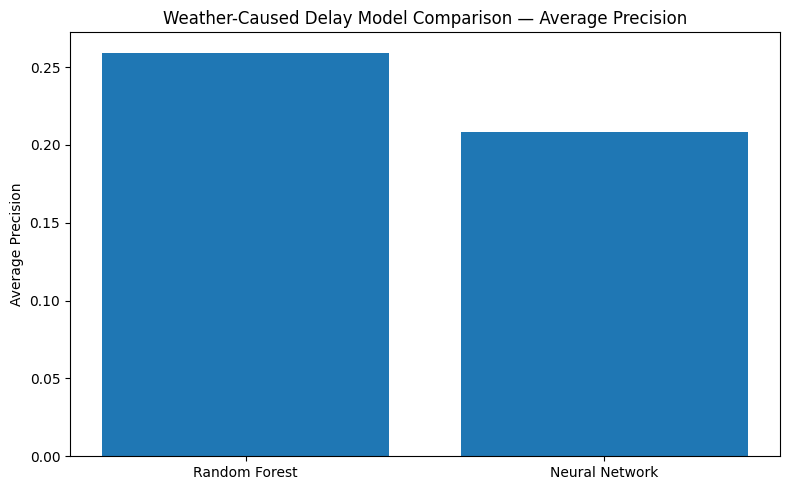

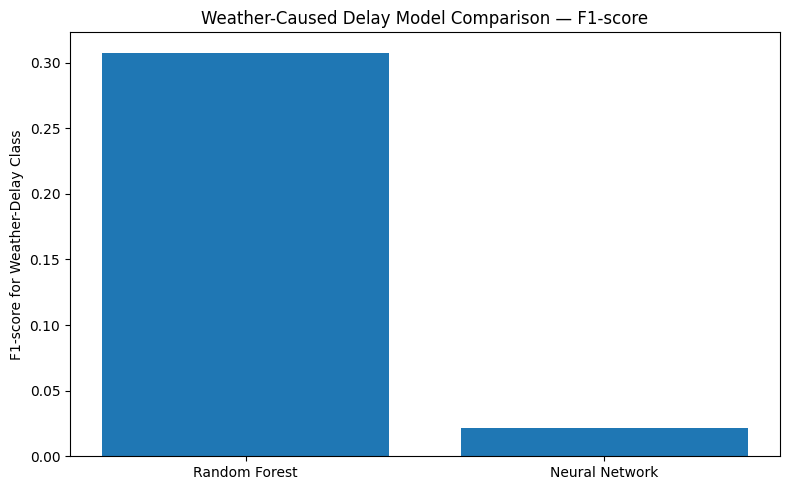

In [37]:
model_comparison = pd.concat([rf_metrics, nn_metrics], ignore_index=True)
display(model_comparison.sort_values(["average_precision", "roc_auc"], ascending=False).reset_index(drop=True))

plt.figure(figsize=(8, 5))
plt.bar(model_comparison["model"], model_comparison["average_precision"])
plt.title("Weather-Caused Delay Model Comparison — Average Precision")
plt.ylabel("Average Precision")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(model_comparison["model"], model_comparison["f1_weather_delay"])
plt.title("Weather-Caused Delay Model Comparison — F1-score")
plt.ylabel("F1-score for Weather-Delay Class")
plt.tight_layout()
plt.show()

## Section 13 — Confusion matrices

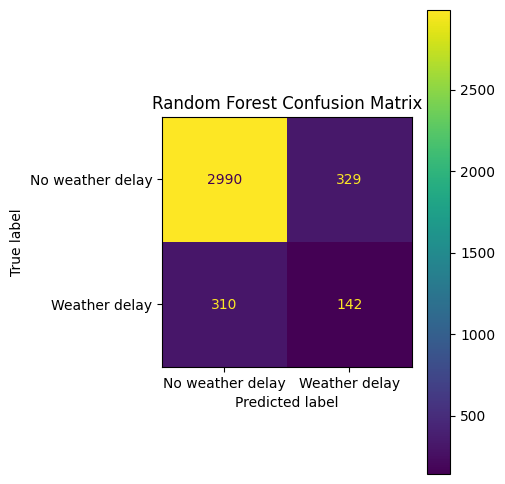

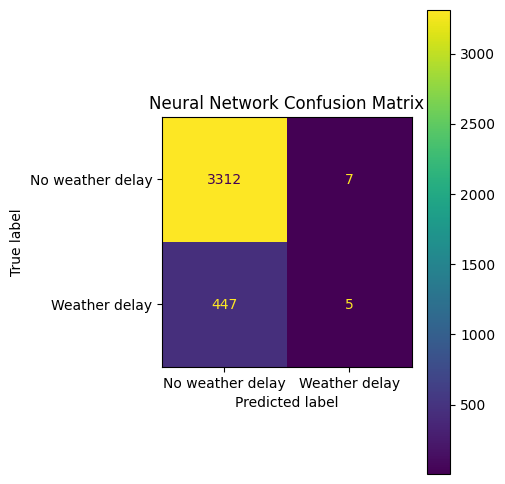

In [38]:
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(y_test, rf_pred, display_labels=["No weather delay", "Weather delay"], ax=ax, values_format="d")
ax.set_title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(y_test, nn_pred, display_labels=["No weather delay", "Weather delay"], ax=ax, values_format="d")
ax.set_title("Neural Network Confusion Matrix")
plt.tight_layout()
plt.show()

## Section 14 — ROC and precision-recall curves

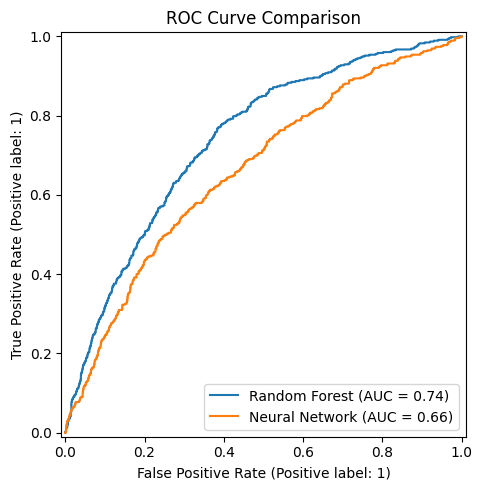

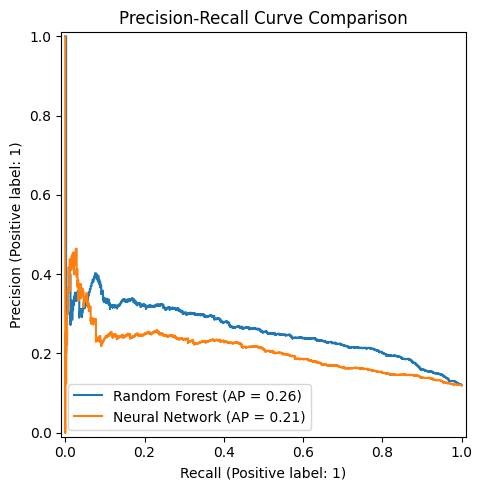

In [39]:
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_test, rf_proba, name="Random Forest", ax=ax)
RocCurveDisplay.from_predictions(y_test, nn_proba, name="Neural Network", ax=ax)
ax.set_title("ROC Curve Comparison")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
PrecisionRecallDisplay.from_predictions(y_test, rf_proba, name="Random Forest", ax=ax)
PrecisionRecallDisplay.from_predictions(y_test, nn_proba, name="Neural Network", ax=ax)
ax.set_title("Precision-Recall Curve Comparison")
plt.tight_layout()
plt.show()

## Section 15 — Threshold comparison

,model,threshold,accuracy,precision_weather_delay,recall_weather_delay,f1_weather_delay
0,Random Forest,0.05,0.188279,0.127179,0.984513,0.225259
1,Random Forest,0.10,0.301246,0.142014,0.957965,0.247358
2,Random Forest,0.15,0.396181,0.155790,0.913717,0.266194
3,Random Forest,0.20,0.484222,0.174160,0.882743,0.290922
4,Random Forest,0.25,0.569345,0.194154,0.823009,0.314189
...,...,...,...,...,...,...
27,Neural Network,0.60,0.879342,0.200000,0.002212,0.004376
28,Neural Network,0.65,0.879873,0.000000,0.000000,0.000000
29,Neural Network,0.70,0.880138,0.000000,0.000000,0.000000
30,Neural Network,0.75,0.880138,0.000000,0.000000,0.000000


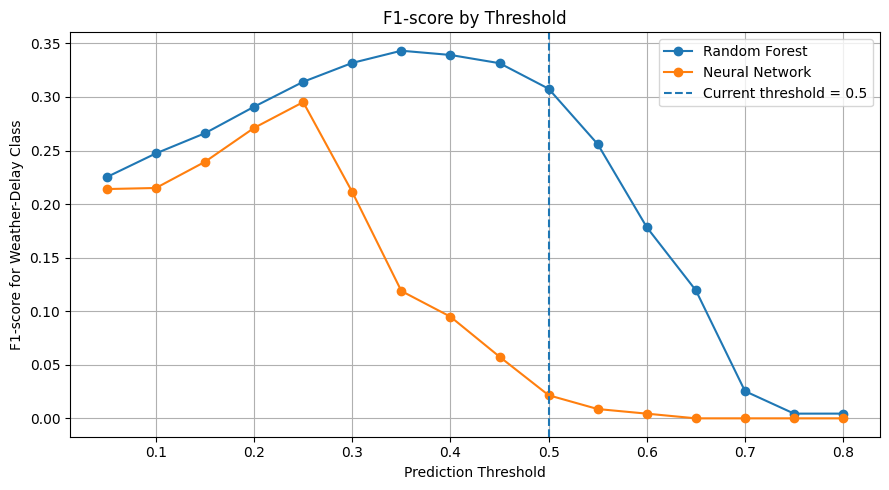

In [40]:
threshold_values = np.arange(0.05, 0.81, 0.05)
threshold_rows = []
for model_name, proba in [("Random Forest", rf_proba), ("Neural Network", nn_proba)]:
    for threshold in threshold_values:
        pred_t = (proba >= threshold).astype(int)
        threshold_rows.append({
            "model": model_name, "threshold": round(float(threshold), 2),
            "accuracy": accuracy_score(y_test, pred_t),
            "precision_weather_delay": precision_score(y_test, pred_t, zero_division=0),
            "recall_weather_delay": recall_score(y_test, pred_t, zero_division=0),
            "f1_weather_delay": f1_score(y_test, pred_t, zero_division=0),
        })
threshold_df = pd.DataFrame(threshold_rows)
display(threshold_df)

plt.figure(figsize=(9, 5))
for model_name in threshold_df["model"].unique():
    part = threshold_df[threshold_df["model"] == model_name]
    plt.plot(part["threshold"], part["f1_weather_delay"], marker="o", label=model_name)
plt.axvline(PREDICTION_THRESHOLD, linestyle="--", label=f"Current threshold = {PREDICTION_THRESHOLD}")
plt.xlabel("Prediction Threshold")
plt.ylabel("F1-score for Weather-Delay Class")
plt.title("F1-score by Threshold")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Section 16 — Select final model

In [41]:
best_model_name = model_comparison.sort_values(["average_precision", "roc_auc"], ascending=False).iloc[0]["model"]
if best_model_name == "Random Forest":
    final_model_template = "Random Forest"
    selected_model = random_forest_model
else:
    final_model_template = "Neural Network"
    selected_model = neural_network_model

display(pd.DataFrame({
    "item": ["Selected final model", "Target", "Selection rule", "Prediction threshold"],
    "value": [best_model_name, "WeatherDelay > 0", "Highest average precision, then ROC AUC", PREDICTION_THRESHOLD]
}))

,item,value
0,Selected final model,Random Forest
1,Target,WeatherDelay > 0
2,Selection rule,"Highest average precision, then ROC AUC"
3,Prediction threshold,0.5


## Section 17 — Train final selected model on all prepared rows

In [42]:
final_X = model_data[all_features]
final_y = model_data["WeatherDelayed"].astype("int8")
if final_model_template == "Random Forest":
    final_model = Pipeline(steps=[
        ("preprocess", rf_preprocess),
        ("model", RandomForestClassifier(n_estimators=200, max_depth=20, min_samples_leaf=10, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1)),
    ])
else:
    final_model = Pipeline(steps=[
        ("preprocess", nn_preprocess),
        ("model", MLPClassifier(hidden_layer_sizes=(64, 32), activation="relu", solver="adam", alpha=0.0005, batch_size=512, learning_rate_init=0.001, max_iter=MLP_MAX_ITER, early_stopping=True, validation_fraction=0.1, n_iter_no_change=8, random_state=RANDOM_STATE, verbose=False)),
    ])
final_model.fit(final_X, final_y)

display(pd.DataFrame({
    "item": ["Final model", "Rows used for final training", "Target", "Features used", "Prediction threshold"],
    "value": [final_model_template, len(final_X), "WeatherDelay > 0", len(all_features), PREDICTION_THRESHOLD]
}))

,item,value
0,Final model,Random Forest
1,Rows used for final training,12338
2,Target,WeatherDelay > 0
3,Features used,34
4,Prediction threshold,0.5


## Section 18 — Final sanity check

,sample_rows,accuracy,precision_weather_delay,recall_weather_delay,f1_weather_delay
0,12338,0.904766,0.581098,0.877249,0.699104


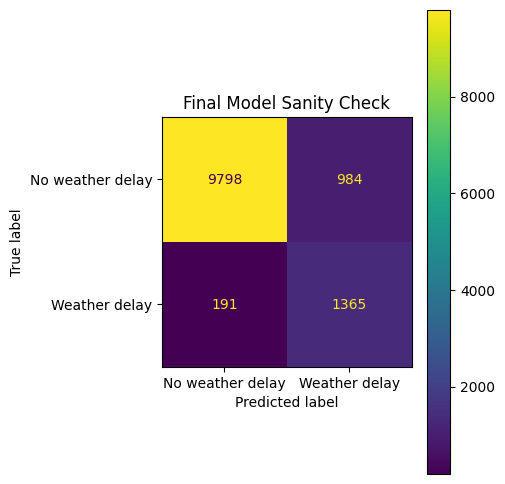

21899

In [43]:
if len(final_X) > 200_000:
    sanity_sample, _ = train_test_split(model_data, train_size=200_000, random_state=RANDOM_STATE, stratify=model_data["WeatherDelayed"])
else:
    sanity_sample = model_data.copy()
X_sanity = sanity_sample[all_features]
y_sanity = sanity_sample["WeatherDelayed"].astype("int8")
sanity_proba = final_model.predict_proba(X_sanity)[:, 1]
sanity_pred = (sanity_proba >= PREDICTION_THRESHOLD).astype(int)

display(pd.DataFrame([{
    "sample_rows": len(sanity_sample),
    "accuracy": accuracy_score(y_sanity, sanity_pred),
    "precision_weather_delay": precision_score(y_sanity, sanity_pred, zero_division=0),
    "recall_weather_delay": recall_score(y_sanity, sanity_pred, zero_division=0),
    "f1_weather_delay": f1_score(y_sanity, sanity_pred, zero_division=0),
}]))

fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(y_sanity, sanity_pred, display_labels=["No weather delay", "Weather delay"], ax=ax, values_format="d")
ax.set_title("Final Model Sanity Check")
plt.tight_layout()
plt.show()

del sanity_sample, X_sanity, y_sanity, sanity_proba, sanity_pred
gc.collect()

## Section 19 — Save final files

In [44]:
joblib.dump(final_model, FINAL_MODEL_FILE)
joblib.dump(PREDICTION_THRESHOLD, FINAL_THRESHOLD_FILE)
save_cols = all_features + ["WeatherDelayed", "WeatherDelay", "FlightDate", "sched_dep_utc", "sched_arr_utc", "Origin", "Dest"]
save_cols = list(dict.fromkeys([col for col in save_cols if col in model_data.columns]))
model_data[save_cols].to_parquet(FINAL_DATASET_FILE, index=False)

display(pd.DataFrame({
    "file": [FINAL_MODEL_FILE, FINAL_THRESHOLD_FILE, FINAL_DATASET_FILE],
    "exists": [Path(FINAL_MODEL_FILE).exists(), Path(FINAL_THRESHOLD_FILE).exists(), Path(FINAL_DATASET_FILE).exists()],
    "size_MB": [
        round(Path(FINAL_MODEL_FILE).stat().st_size/1024**2, 2) if Path(FINAL_MODEL_FILE).exists() else None,
        round(Path(FINAL_THRESHOLD_FILE).stat().st_size/1024**2, 2) if Path(FINAL_THRESHOLD_FILE).exists() else None,
        round(Path(FINAL_DATASET_FILE).stat().st_size/1024**2, 2) if Path(FINAL_DATASET_FILE).exists() else None,
    ]
}))

,file,exists,size_MB
0,final_weather_cause_delay_model.joblib,True,12.9
1,final_weather_cause_prediction_threshold.joblib,True,0.0
2,final_weather_cause_modeling_dataset.parquet,True,0.6


## Section 20 — Test loading the saved model

In [45]:
loaded_model = joblib.load(FINAL_MODEL_FILE)
loaded_threshold = joblib.load(FINAL_THRESHOLD_FILE)
sample_rows = final_X.head(10).copy()
sample_proba = loaded_model.predict_proba(sample_rows)[:, 1]
sample_pred = (sample_proba >= loaded_threshold).astype(int)
sample_output = sample_rows.copy()
sample_output["weather_delay_probability"] = sample_proba
sample_output["predicted_weather_delay"] = sample_pred
display(sample_output)

,origin_wx_tmpf,origin_wx_dwpf,origin_wx_relh,origin_wx_drct,origin_wx_sknt,origin_wx_p01i,origin_wx_alti,origin_wx_mslp,origin_wx_vsby,origin_wx_gust,origin_wx_feel,origin_wx_rain,origin_wx_snow,origin_wx_fog,origin_wx_thunder,dest_wx_tmpf,dest_wx_dwpf,dest_wx_relh,dest_wx_drct,dest_wx_sknt,dest_wx_p01i,dest_wx_alti,dest_wx_mslp,dest_wx_vsby,dest_wx_gust,dest_wx_feel,dest_wx_rain,dest_wx_snow,dest_wx_fog,dest_wx_thunder,origin_wx_skyc1,origin_wx_skyc2,dest_wx_skyc1,dest_wx_skyc2,weather_delay_probability,predicted_weather_delay
0,28.9,24.1,82.000000,20.0,10.0,NaN,30.240000,1024.900024,10.0,NaN,19.080000,0,0,0,0,34.0,32.0,92.290001,330.0,6.0,0.00,30.299999,1026.400024,5.00,NaN,27.940001,0,0,1,0,OVC,NONE,OVC,NONE,0.284482,0
1,26.1,21.9,83.889999,340.0,5.0,0.00,30.299999,1027.099976,10.0,NaN,19.389999,0,0,0,0,32.0,30.9,95.650002,310.0,5.0,0.00,30.340000,NaN,2.50,NaN,26.400000,0,0,1,0,OVC,NONE,OVC,NONE,0.415538,0
2,26.1,23.0,87.870003,350.0,4.0,0.00,30.299999,NaN,10.0,NaN,20.530001,0,0,0,0,30.0,30.0,100.000000,310.0,6.0,0.00,30.320000,1027.300049,0.75,NaN,23.120001,0,0,1,0,OVC,NONE,OVC,NONE,0.454226,0
3,28.0,19.9,71.250000,260.0,9.0,0.00,30.040001,1018.200012,10.0,NaN,18.540001,0,0,0,0,28.0,24.1,85.080002,260.0,8.0,0.00,30.120001,1020.599976,10.00,NaN,19.190001,0,0,0,0,FEW,OVC,CLR,NONE,0.315683,0
4,51.0,50.0,96.000000,220.0,13.0,0.02,29.490000,998.900024,4.0,25.0,51.099998,1,0,1,0,61.0,53.0,75.199997,230.0,14.0,0.00,29.680000,1005.000000,10.00,24.0,61.000000,0,0,0,0,OVC,NONE,FEW,NONE,0.347617,0
5,42.0,38.0,84.930000,270.0,13.0,0.00,29.740000,1007.299988,10.0,NaN,34.509998,0,0,0,0,47.0,40.0,76.480003,240.0,3.0,0.00,29.840000,1010.599976,10.00,NaN,45.720001,0,0,0,0,BKN,NONE,CLR,NONE,0.133703,0
6,30.0,21.0,68.809998,140.0,6.0,0.00,30.299999,1027.000000,10.0,NaN,23.120001,0,0,0,0,28.0,26.1,92.459999,130.0,7.0,0.02,30.260000,NaN,1.00,NaN,19.900000,0,1,1,0,OVC,NONE,VV,NONE,0.496567,0
7,30.9,21.0,66.339996,30.0,13.0,0.00,30.360001,1028.800049,10.0,NaN,20.160000,0,0,0,0,28.9,21.9,74.760002,30.0,8.0,0.00,30.360001,NaN,10.00,NaN,20.290001,0,0,0,0,SCT,BKN,BKN,NONE,0.224070,0
8,23.0,19.9,87.699997,260.0,9.0,0.00,30.260000,1025.699951,6.0,NaN,12.320000,0,0,1,0,28.0,26.1,92.459999,260.0,9.0,0.00,30.320000,1027.800049,8.00,NaN,18.540001,0,0,0,0,OVC,NONE,OVC,NONE,0.473579,0
9,34.0,28.9,81.370003,260.0,3.0,0.00,29.980000,1015.900024,5.0,NaN,30.969999,0,0,0,0,34.0,32.0,92.290001,290.0,8.0,0.00,30.040001,NaN,2.00,NaN,26.580000,0,0,1,0,BKN,OVC,OVC,NONE,0.426718,0


## Section 21 — Final conclusion

In [46]:
final_conclusion = (
    "This notebook targets weather-caused delay only. "
    "The target label is WeatherDelayed = 1 when the official WeatherDelay column is greater than 0. "
    "Flight data is used to define the target and match scheduled origin/destination weather, but actual delay columns are not used as model features. "
    "Random Forest and Neural Network models are compared using classification metrics, confusion matrices, ROC curves, and precision-recall curves."
)
print(final_conclusion)

This notebook targets weather-caused delay only. The target label is WeatherDelayed = 1 when the official WeatherDelay column is greater than 0. Flight data is used to define the target and match scheduled origin/destination weather, but actual delay columns are not used as model features. Random Forest and Neural Network models are compared using classification metrics, confusion matrices, ROC curves, and precision-recall curves.


In [47]:
# Section — Train Gradient Boosting model

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import OrdinalEncoder
from sklearn.utils.class_weight import compute_sample_weight

# Gradient boosting works better with ordinal-encoded categoricals than one-hot for this setup
gb_preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median"))
        ]), numeric_weather_features),

        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("ordinal", OrdinalEncoder(
                handle_unknown="use_encoded_value",
                unknown_value=-1
            ))
        ]), categorical_weather_features),
    ],
    remainder="drop"
)

gradient_boosting_model = Pipeline(steps=[
    ("preprocess", gb_preprocess),
    ("model", HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=0.05,
        max_leaf_nodes=31,
        min_samples_leaf=30,
        l2_regularization=0.1,
        random_state=RANDOM_STATE
    ))
])

# Give more weight to the minority class
gb_sample_weight = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

gradient_boosting_model.fit(
    X_train,
    y_train,
    model__sample_weight=gb_sample_weight
)

gb_proba = gradient_boosting_model.predict_proba(X_test)[:, 1]
gb_pred = (gb_proba >= PREDICTION_THRESHOLD).astype(int)

gb_metrics = pd.DataFrame([{
    "model": "Gradient Boosting",
    "target": "WeatherDelay >= 30",
    "prediction_threshold": PREDICTION_THRESHOLD,
    "accuracy": accuracy_score(y_test, gb_pred),
    "precision_weather_delay": precision_score(y_test, gb_pred, zero_division=0),
    "recall_weather_delay": recall_score(y_test, gb_pred, zero_division=0),
    "f1_weather_delay": f1_score(y_test, gb_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, gb_proba),
    "average_precision": average_precision_score(y_test, gb_proba),
}])

display(gb_metrics)

,model,target,prediction_threshold,accuracy,precision_weather_delay,recall_weather_delay,f1_weather_delay,roc_auc,average_precision
0,Gradient Boosting,WeatherDelay >= 30,0.5,0.815964,0.271698,0.318584,0.293279,0.690009,0.227597


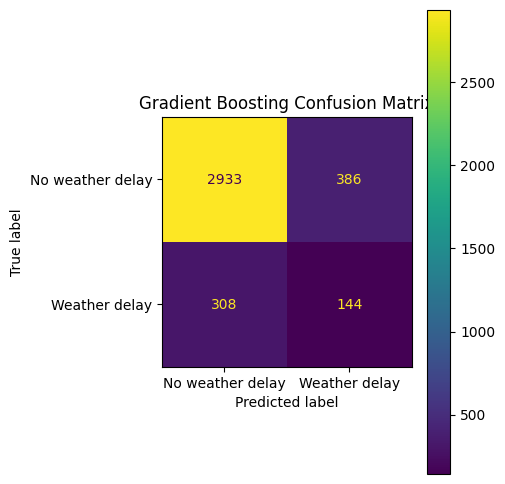

In [48]:
# Section — Gradient Boosting confusion matrix

fig, ax = plt.subplots(figsize=(5, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    gb_pred,
    display_labels=["No weather delay", "Weather delay"],
    ax=ax,
    values_format="d"
)

ax.set_title("Gradient Boosting Confusion Matrix")
plt.tight_layout()
plt.show()